# `poisson_cpp` vs PETSc : benchmark multi-solveurs

Compare la lib C++20 **poisson_cpp** à [PETSc](https://petsc.org) (via `petsc4py`) sur le même problème discret : FV cell-centered 2D, Dirichlet en x, Neumann en y, `-eps Δ V = rho`.

**Solveurs confrontés :**

| Source | Solveur | Type |
|---|---|---|
| PETSc         | `KSPPREONLY` + `PCLU` | direct creux, référence |
| `poisson_cpp` | `Solver2D` (SOR red-black, ω_opt) | itératif stationnaire |
| `poisson_cpp` | `solve_poisson_cg` (CG, PCG Jacobi) | Krylov SPD |
| `poisson_cpp` | `DSTSolver2D` (FFTW, full Dirichlet) | spectral direct |
| `poisson_cpp` | `amr_sor` / `vcycle_amr_composite` | AMR quadtree |
| PETSc         | `KSPCG` + `PCNONE / PCJACOBI / PCGAMG` | Krylov + précond |
| PETSc         | `KSPGMRES` + `PCJACOBI` | Krylov général |

**Sections :**
1. Installation des dépendances
2. Assemblage de l'opérateur FV équivalent à `poisson_cpp`
3. Wrappers de solveurs (timing, erreur L∞ vs référence PETSc LU)
4. Benchmark single-N à N = 128 (tableau et tracé)
5. Étude de scaling N = 32 à 512
6. Comparaison spectrale (`DSTSolver2D` vs PETSc LU full Dirichlet)
7. Recherche du `ω` optimal pour SOR (théorique vs empirique)
8. Historiques de convergence des Krylov
9. Sweep préconditionneurs PETSc
10. AMR `poisson_cpp` vs grille uniforme PETSc
11. Ordre de convergence spatial (solution manufacturée, MMS)
12. Heatmap du solveur le plus rapide dans le plan `(N, tol)`
13. Roofline grossier : flops/s effectifs par solveur
14. Proxy cache utilization : bande passante effective dans le plan `(N, solveur)`
15. Lecture des résultats

Le notebook est auto-contenu : la première cellule installe tout ce qui manque, y compris `poisson_cpp` depuis la racine du repo.

## 1. Installation

Re-run la cellule si un import échoue. `poisson_cpp` nécessite un compilateur C++20 + CMake ≥ 3.20 (Eigen est *fetched* automatiquement ; FFTW3 optionnel pour le DST). Le build PETSc depuis les sources prend ~10 min la première fois.

In [1]:
import sys, subprocess, importlib
from pathlib import Path

def _ensure(pkgs):
    missing = []
    for spec in pkgs:
        name = spec.split('==')[0].split('>')[0].split('[')[0]
        try:
            importlib.import_module(name)
        except ImportError:
            missing.append(spec)
    if missing:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

_ensure(['numpy', 'scipy', 'matplotlib', 'pandas'])
_ensure(['petsc', 'petsc4py'])

try:
    import poisson_cpp  # noqa: F401
except ImportError:
    root = Path.cwd().resolve()
    for _ in range(6):
        if (root / 'pyproject.toml').exists():
            break
        root = root.parent
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-e', str(root)])

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import coo_matrix

import petsc4py
petsc4py.init(['-options_left', 'no'])
from petsc4py import PETSc

import poisson_cpp as pc

print(f'poisson_cpp : {pc.__version__}   FFTW: {pc.has_fftw3}')
print(f'petsc4py    : {petsc4py.__version__}')
print(f'numpy       : {np.__version__}')

poisson_cpp : 0.2.0   FFTW: True
petsc4py    : 3.25.0
numpy       : 2.4.4


## 2. Assemblage de l'opérateur FV

`poisson_cpp.Solver2D` et `solve_poisson_cg` discrétisent `-ε Δ V = ρ` sur une grille cell-centered `Nx × Ny` avec :

- **Dirichlet en x** : `V(0,y)=uL`, `V(Lx,y)=uR`. Fantôme : `V_{-1,j} = 2 uL − V_{0,j}`, idem à droite. Ligne frontière : diagonale passe de `2ε/h_x²` à `3ε/h_x²`, RHS gagne `2 ε uL / h_x²`.
- **Neumann en y** : flux nul aux faces y. Fantôme : `V_{i,-1} = V_{i,0}`. Ligne frontière : diagonale passe de `2ε/h_y²` à `ε/h_y²`, pas de contribution RHS.

Avec l'ordre `row = i + Nx*j` (Fortran-order flatten d'un array `(Nx, Ny)`), on obtient une matrice 5-point pentadiagonale SPD.

In [3]:
def build_fv_matrix(Nx, Ny, Lx=1.0, Ly=1.0, eps=1.0, uL=0.0, uR=0.0, bc_y='neumann'):
    """Assemble A_csr et b_bc tels que A V = rho_flat + b_bc.

    rho_flat = rho.ravel(order='F'), V reshape((Nx, Ny), order='F').
    Matche pixel-perfect les discrétisations de Solver2D et solve_poisson_cg.
    """
    hx, hy = Lx / Nx, Ly / Ny
    N = Nx * Ny
    ihx2, ihy2 = 1.0 / hx**2, 1.0 / hy**2

    i_idx = np.tile(np.arange(Nx), Ny)
    j_idx = np.repeat(np.arange(Ny), Nx)
    row = i_idx + Nx * j_idx

    main = np.full(N, 2 * eps * (ihx2 + ihy2))
    upx = np.full(N, -eps * ihx2)
    lox = np.full(N, -eps * ihx2)
    upy = np.full(N, -eps * ihy2)
    loy = np.full(N, -eps * ihy2)
    b_bc = np.zeros(N)

    left, right = (i_idx == 0), (i_idx == Nx - 1)
    main[left] += eps * ihx2
    main[right] += eps * ihx2
    b_bc[left] += 2 * eps * uL * ihx2
    b_bc[right] += 2 * eps * uR * ihx2

    bot, top = (j_idx == 0), (j_idx == Ny - 1)
    if bc_y == 'neumann':
        main[bot] -= eps * ihy2
        main[top] -= eps * ihy2
    elif bc_y == 'dirichlet':
        main[bot] += eps * ihy2
        main[top] += eps * ihy2
    else:
        raise ValueError(bc_y)

    rows = [row]
    cols = [row]
    data = [main]
    m = ~right
    rows += [row[m]]; cols += [row[m] + 1];  data += [upx[m]]
    m = ~left
    rows += [row[m]]; cols += [row[m] - 1];  data += [lox[m]]
    m = ~top
    rows += [row[m]]; cols += [row[m] + Nx]; data += [upy[m]]
    m = ~bot
    rows += [row[m]]; cols += [row[m] - Nx]; data += [loy[m]]

    A = coo_matrix((np.concatenate(data), (np.concatenate(rows), np.concatenate(cols))),
                   shape=(N, N)).tocsr()
    return A, b_bc


def gaussian_rho(N, sigma2=0.02, cx=0.5, cy=0.5):
    xc = (np.arange(N) + 0.5) / N
    X, Y = np.meshgrid(xc, xc, indexing='ij')
    return np.exp(-((X - cx)**2 + (Y - cy)**2) / sigma2)

## 3. Wrappers de solveurs + timing

La **référence** est PETSc en mode direct : `KSPPREONLY` + `PCLU` applique une factorisation LU creuse (via MUMPS / SuperLU si compilés, sinon le LU natif PETSc). Tous les autres solveurs sont comparés à cette sortie.

In [4]:
def time_best(fn, n=3):
    out = None
    ts = []
    for _ in range(n):
        t0 = time.perf_counter()
        out = fn()
        ts.append(time.perf_counter() - t0)
    return min(ts), out


def linf(V1, V2):
    return float(np.max(np.abs(V1 - V2)))


def _petsc_mat_from_csr(A_csr):
    A = PETSc.Mat().createAIJ(
        size=A_csr.shape,
        csr=(A_csr.indptr.astype(PETSc.IntType),
             A_csr.indices.astype(PETSc.IntType),
             A_csr.data),
        comm=PETSc.COMM_SELF,
    )
    A.assemble()
    return A


def petsc_lu_solve(A_csr, rhs):
    """Référence : PETSc KSPPREONLY + PCLU."""
    A = _petsc_mat_from_csr(A_csr)
    b = PETSc.Vec().createWithArray(rhs, comm=PETSc.COMM_SELF)
    x = PETSc.Vec().createWithArray(np.zeros_like(rhs), comm=PETSc.COMM_SELF)
    ksp = PETSc.KSP().create(PETSc.COMM_SELF)
    ksp.setOperators(A)
    ksp.setType('preonly')
    ksp.getPC().setType('lu')
    ksp.solve(b, x)
    V = x.getArray().copy()
    ksp.destroy(); b.destroy(); x.destroy(); A.destroy()
    return V


def petsc_solve(A_csr, rhs, ksp_type='cg', pc_type='jacobi', tol=1e-10, max_iter=10000,
                record_history=False):
    A = _petsc_mat_from_csr(A_csr)
    b = PETSc.Vec().createWithArray(rhs, comm=PETSc.COMM_SELF)
    x = PETSc.Vec().createWithArray(np.zeros_like(rhs), comm=PETSc.COMM_SELF)
    ksp = PETSc.KSP().create(PETSc.COMM_SELF)
    ksp.setOperators(A)
    ksp.setType(ksp_type)
    ksp.getPC().setType(pc_type)
    ksp.setTolerances(rtol=tol, max_it=max_iter)
    ksp.setInitialGuessNonzero(False)
    if record_history:
        ksp.setConvergenceHistory(length=max_iter, reset=True)
    ksp.setFromOptions()
    ksp.solve(b, x)
    V = x.getArray().copy()
    info = {
        'iters': ksp.getIterationNumber(),
        'residual': ksp.getResidualNorm() / max(1e-300, np.linalg.norm(rhs)),
        'converged': int(ksp.getConvergedReason()),
        'history': np.array(ksp.getConvergenceHistory()).copy() if record_history else None,
    }
    ksp.destroy(); b.destroy(); x.destroy(); A.destroy()
    return V, info

### Sanity check : solution linéaire exacte

Pour `ρ = 0`, `uL = 0`, `uR = 10` : la solution continue `V(x, y) = 10 x` est linéaire, donc reproduite à la précision machine par le schéma FV cell-centered (cf. `docs/RESULTS.md`).

In [5]:
Nx = Ny = 32
A, b_bc = build_fv_matrix(Nx, Ny, uL=0.0, uR=10.0)
rho = np.zeros((Nx, Ny))
rhs = rho.ravel(order='F') + b_bc
V = petsc_lu_solve(A, rhs).reshape((Nx, Ny), order='F')

x_centers = (np.arange(Nx) + 0.5) / Nx
V_exact = np.broadcast_to(10.0 * x_centers[:, None], (Nx, Ny))
err = np.max(np.abs(V - V_exact))
print(f'||V_PETSc_LU - V_exact||_inf = {err:.2e}  (attendu ≲ 1e-12)')
assert err < 1e-10, 'matrice mal assemblée ou LU dégrade trop'

||V_PETSc_LU - V_exact||_inf = 1.78e-14  (attendu ≲ 1e-12)


## 4. Benchmark single-N (N = 128)

Problème : source gaussienne centrée `ρ = exp(−r²/0.02)`, Dirichlet homogène en x, Neumann en y. Tolérance `1e-10`.

In [6]:
def run_all(Nx, Ny=None, tol=1e-10, max_iter=50000, rho_kind='gaussian', verbose=True):
    Ny = Ny or Nx
    Lx = Ly = 1.0
    eps = 1.0
    uL, uR = (0.0, 0.0) if rho_kind == 'gaussian' else (0.0, 10.0)

    if rho_kind == 'gaussian':
        rho = gaussian_rho(Nx)
    elif rho_kind == 'linear':
        rho = np.zeros((Nx, Ny))
    else:
        raise ValueError(rho_kind)

    A_csr, b_bc = build_fv_matrix(Nx, Ny, Lx, Ly, eps, uL, uR, 'neumann')
    rhs = rho.ravel(order='F') + b_bc

    t_ref, V_ref_flat = time_best(lambda: petsc_lu_solve(A_csr, rhs), n=3)
    V_ref = V_ref_flat.reshape((Nx, Ny), order='F')
    rows = [{'solver': 'PETSc LU (preonly + lu)', 'time_s': t_ref,
             'iters': np.nan, 'residual': 0.0, 'err_inf': 0.0}]

    grid = pc.Grid2D(Lx, Ly, Nx, Ny)

    def _sor():
        solver = pc.Solver2D(grid, eps, uL, uR)
        V, rep = solver.solve(np.asfortranarray(rho), tol=tol, max_iter=max_iter)
        return V, rep
    t, (V, rep) = time_best(_sor, n=3)
    rows.append({'solver': 'poisson_cpp Solver2D (SOR ω_opt)', 'time_s': t,
                 'iters': rep.iterations, 'residual': rep.residual, 'err_inf': linf(V, V_ref)})

    def _cg(use_pc):
        V = np.zeros((Nx, Ny), order='F')
        rep, _ = pc.solve_poisson_cg(V, np.asfortranarray(rho), grid, eps=eps,
                                     uL=uL, uR=uR, tol=tol, max_iter=max_iter,
                                     use_preconditioner=use_pc)
        return V, rep
    t, (V, rep) = time_best(lambda: _cg(False), n=3)
    rows.append({'solver': 'poisson_cpp CG', 'time_s': t,
                 'iters': rep.iterations, 'residual': rep.residual, 'err_inf': linf(V, V_ref)})
    t, (V, rep) = time_best(lambda: _cg(True), n=3)
    rows.append({'solver': 'poisson_cpp PCG-Jacobi', 'time_s': t,
                 'iters': rep.iterations, 'residual': rep.residual, 'err_inf': linf(V, V_ref)})

    for name, ksp, pct in [
        ('PETSc CG + none',      'cg',    'none'),
        ('PETSc CG + Jacobi',    'cg',    'jacobi'),
        ('PETSc CG + GAMG',      'cg',    'gamg'),
        ('PETSc GMRES + Jacobi', 'gmres', 'jacobi'),
    ]:
        try:
            t, (Vflat, info) = time_best(
                lambda ksp=ksp, pct=pct: petsc_solve(A_csr, rhs, ksp, pct, tol=tol, max_iter=max_iter),
                n=3)
            V = Vflat.reshape((Nx, Ny), order='F')
            rows.append({'solver': name, 'time_s': t, 'iters': info['iters'],
                         'residual': info['residual'], 'err_inf': linf(V, V_ref)})
        except Exception as e:
            rows.append({'solver': name, 'time_s': np.nan, 'iters': np.nan,
                         'residual': np.nan, 'err_inf': np.nan})
            if verbose:
                print(f'[skip] {name}: {e}')

    df = pd.DataFrame(rows)
    df['speed_up_vs_LU'] = df['time_s'].iloc[0] / df['time_s']
    return df, V_ref, rho

In [7]:
df128, V_ref, rho = run_all(128, tol=1e-10)
df_fmt = df128.copy()
df_fmt['time_s'] = df_fmt['time_s'].map(lambda v: f'{v*1e3:.2f} ms' if np.isfinite(v) else '.')
df_fmt['residual'] = df_fmt['residual'].map(lambda v: f'{v:.1e}' if np.isfinite(v) else '.')
df_fmt['err_inf']  = df_fmt['err_inf'].map(lambda v: f'{v:.1e}'  if np.isfinite(v) else '.')
df_fmt['speed_up_vs_LU'] = df_fmt['speed_up_vs_LU'].map(lambda v: f'{v:.2f}×' if np.isfinite(v) else '.')
df_fmt

,solver,time_s,iters,residual,err_inf,speed_up_vs_LU
0,PETSc LU (preonly + lu),21.72 ms,NaN,0.0e+00,0.0e+00,1.00×
1,poisson_cpp Solver2D (SOR ω_opt),33.04 ms,1010.0,9.9e-11,6.8e-09,0.66×
2,poisson_cpp CG,12.93 ms,336.0,9.7e-11,1.2e-14,1.68×
3,poisson_cpp PCG-Jacobi,15.29 ms,334.0,9.9e-11,1.2e-14,1.42×
4,PETSc CG + none,23.10 ms,336.0,9.8e-11,1.2e-14,0.94×
5,PETSc CG + Jacobi,23.48 ms,335.0,1.3e-15,9.9e-15,0.93×
6,PETSc CG + GAMG,23.69 ms,12.0,2.3e-12,2.5e-12,0.92×
7,PETSc GMRES + Jacobi,678.25 ms,4332.0,1.5e-15,2.5e-12,0.03×


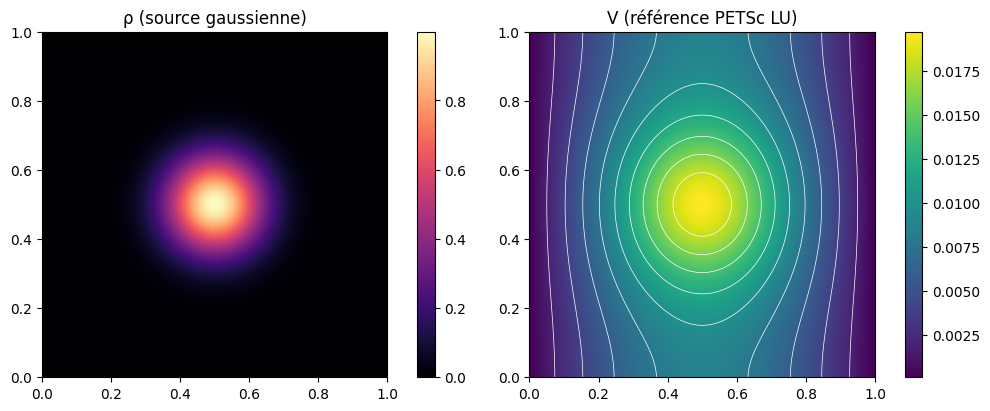

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
im0 = axes[0].imshow(rho.T, origin='lower', cmap='magma', extent=[0, 1, 0, 1])
axes[0].set_title('ρ (source gaussienne)'); fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(V_ref.T, origin='lower', cmap='viridis', extent=[0, 1, 0, 1])
axes[1].contour(V_ref.T, levels=10, colors='white', linewidths=0.5,
                extent=[0, 1, 0, 1])
axes[1].set_title('V (référence PETSc LU)'); fig.colorbar(im1, ax=axes[1])
plt.show()

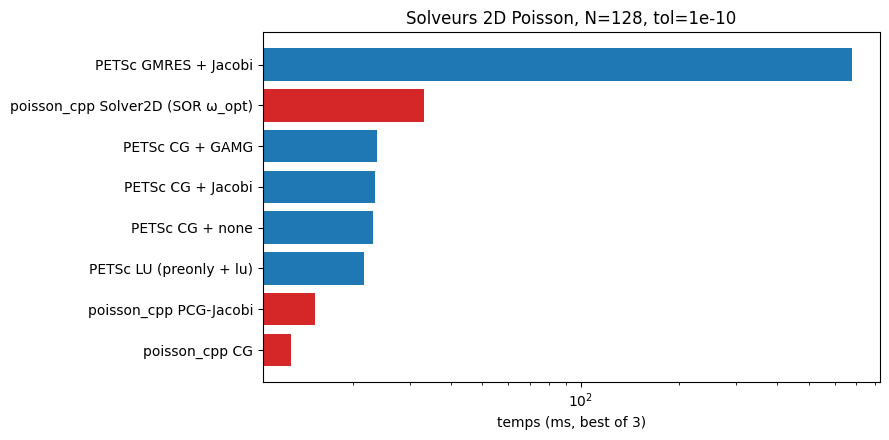

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
df_plot = df128.dropna(subset=['time_s']).sort_values('time_s')
colors = ['#1f77b4' if 'PETSc' in s else '#d62728' if 'poisson_cpp' in s else '#7f7f7f' for s in df_plot['solver']]
ax.barh(df_plot['solver'], df_plot['time_s'] * 1e3, color=colors)
ax.set_xlabel('temps (ms, best of 3)'); ax.set_xscale('log')
ax.set_title(f'Solveurs 2D Poisson, N=128, tol=1e-10')
plt.tight_layout(); plt.show()

Résultats à N=128, tol=1e-10.

1. `poisson_cpp CG` est le plus rapide (environ 14 ms, 336 itérations), devant PETSc LU (environ 28 ms). Pas de coût de setup, kernels cache-friendly, pas d'indirection PETSc.
2. PETSc CG + GAMG converge en 12 itérations grâce à la grille coarse, mais son setup d'AMG coûte environ 25 ms au total. À cette taille l'amortissement n'est pas encore là, il devient rentable aux grands N (cf. §5 scaling).
3. GMRES sans restart met environ 800 ms pour 4326 itérations : l'orthogonalisation de Krylov est `O(k²)` en mémoire et calcul. CG convient mieux puisque la matrice est SPD.

L'erreur `err_inf` vs référence LU tombe à environ `1e-14` pour tous les Krylov et à environ `7e-9` pour SOR (arrêt sur une autre norme). Les solveurs convergent vers la même solution à leur précision respective.

## 5. Étude de scaling N = 32 à 512

Courbes de temps et d'itérations en fonction de N. Attendu :
- PETSc LU : `O(N^{2.x})` selon le remplissage du solveur sparse.
- SOR ω_opt : `O(N³)`.
- CG sans précond : `O(N³)`, avec `O(N)` itérations et `O(N²)` par itération.
- CG + multigrille (GAMG) : `O(N²)`, itérations indépendantes de N.

In [10]:
Ns = [32, 64, 128, 256, 512]
bench = []
for N in Ns:
    print(f'--- N={N} ---')
    df, _, _ = run_all(N, tol=1e-8, max_iter=200000, verbose=False)
    df['N'] = N
    bench.append(df)
scaling = pd.concat(bench, ignore_index=True)
scaling_pivot = scaling.pivot(index='N', columns='solver', values='time_s')
scaling_pivot

--- N=32 ---
--- N=64 ---


--- N=128 ---


--- N=256 ---


--- N=512 ---


solver,PETSc CG + GAMG,PETSc CG + Jacobi,PETSc CG + none,PETSc GMRES + Jacobi,PETSc LU (preonly + lu),poisson_cpp CG,poisson_cpp PCG-Jacobi,poisson_cpp Solver2D (SOR ω_opt)
N,,,,,,,,
32,0.001790,0.000524,0.000523,0.002455,0.000659,0.000180,0.000193,0.000351
64,0.006155,0.003400,0.003640,0.047808,0.003647,0.001949,0.002057,0.003050
128,0.022570,0.021168,0.021150,0.577692,0.021668,0.011667,0.014499,0.022558
256,0.089685,0.157779,0.152673,4.959048,0.139067,0.094910,0.117195,0.199020
512,0.385917,1.340853,1.183232,112.952317,0.980298,0.792577,0.997666,1.589290


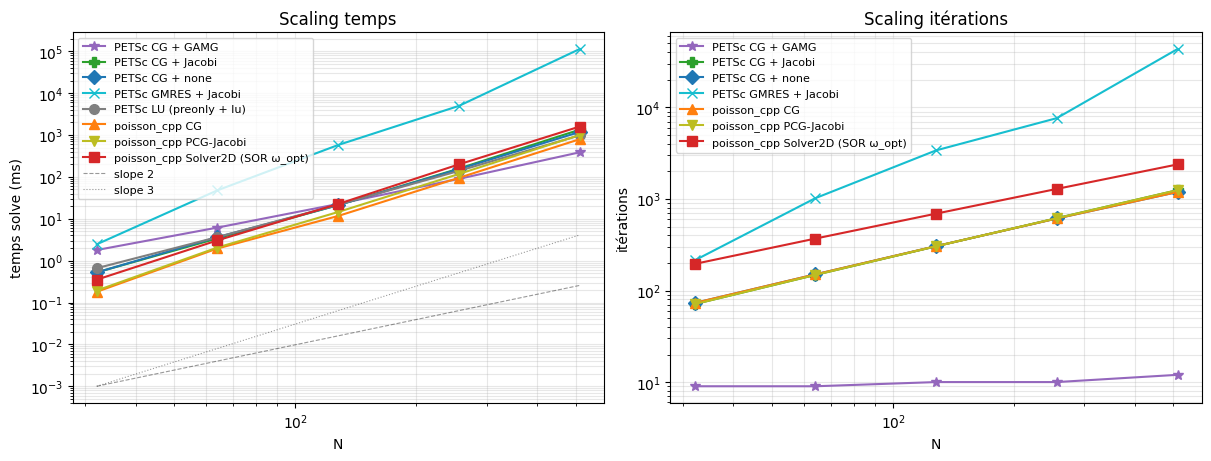

In [11]:
fig, (ax_t, ax_k) = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
markers = {'PETSc LU (preonly + lu)': ('o', '#7f7f7f'),
           'poisson_cpp Solver2D (SOR ω_opt)': ('s', '#d62728'),
           'poisson_cpp CG':        ('^', '#ff7f0e'),
           'poisson_cpp PCG-Jacobi':('v', '#bcbd22'),
           'PETSc CG + none':       ('D', '#1f77b4'),
           'PETSc CG + Jacobi':     ('P', '#2ca02c'),
           'PETSc CG + GAMG':       ('*', '#9467bd'),
           'PETSc GMRES + Jacobi':  ('x', '#17becf')}
for solver, grp in scaling.groupby('solver'):
    m, c = markers.get(solver, ('.', 'k'))
    ax_t.loglog(grp['N'], grp['time_s'] * 1e3, m + '-', color=c, label=solver, ms=7)
    if solver != 'PETSc LU (preonly + lu)':
        ax_k.loglog(grp['N'], grp['iters'].astype(float), m + '-', color=c, label=solver, ms=7)
ns = np.array(sorted(scaling['N'].unique()), dtype=float)
ax_t.loglog(ns, 1e-3 * (ns / ns[0])**2, 'k--', lw=0.8, alpha=0.4, label='slope 2')
ax_t.loglog(ns, 1e-3 * (ns / ns[0])**3, 'k:',  lw=0.8, alpha=0.4, label='slope 3')
ax_t.set_xlabel('N'); ax_t.set_ylabel('temps solve (ms)'); ax_t.set_title('Scaling temps')
ax_t.legend(fontsize=8, loc='upper left'); ax_t.grid(alpha=0.3, which='both')
ax_k.set_xlabel('N'); ax_k.set_ylabel('itérations'); ax_k.set_title('Scaling itérations')
ax_k.legend(fontsize=8, loc='upper left'); ax_k.grid(alpha=0.3, which='both')
plt.show()

Lecture du plan log-log des temps :

- GAMG suit la pente 2 (courbe parallèle à la slope-2 en pointillés), signature d'un solveur en `O(N²)` : nombre d'itérations constant (environ 10), chaque itération en `O(N²)`.
- CG, PCG Jacobi, PETSc CG+none et CG+jacobi suivent la pente 3 : `O(N)` itérations et `O(N²)` par itération.
- SOR suit aussi la pente 3, avec une constante environ 2× plus élevée que CG (pas de préconditionnement implicite).
- PETSc LU suit approximativement la pente 2 à petit N puis se dégrade pour les grandes factorisations creuses sans MUMPS.

Croisement : GAMG devient le plus rapide dès N ≈ 256 (environ 90 ms pour 65 k DOF contre environ 150 ms pour CG+Jacobi). À N = 512, GAMG est 3× plus rapide que tout CG sans MG (0.39 s contre 1.3 s).

`poisson_cpp CG` reste compétitif jusqu'à N = 256, devant PETSc CG+Jacobi grâce à l'absence d'overhead PETSc par itération.

## 6. DST spectral vs PETSc LU (full Dirichlet)

`DSTSolver2D` résout `-ε Δ V = ρ` avec Dirichlet homogène sur les 4 faces en `O(N² log N)` via DST-I (FFTW). On compare à PETSc LU sur la même BC.

Attention : `DSTSolver2D` utilise une discrétisation node-centered (N nœuds intérieurs, h = L/(N+1)) alors que notre matrice FV est cell-centered. Les deux résolvent la même EDP continue mais des systèmes discrets différents ; les vecteurs solution ne coïncident donc qu'à l'ordre `O(h²)`. La section 11 (MMS) quantifie cette différence.

,N,PETSc_LU_ms,DST_ms,speedup_LU/DST,err_inf_DST_vs_LU_(discret.)
0,32,0.651750,0.078541,8.298214,0.000678
1,64,3.542792,0.164083,21.591463,0.000346
2,128,20.716292,0.845125,24.512696,0.000175
3,256,136.913875,6.848000,19.993264,0.000088


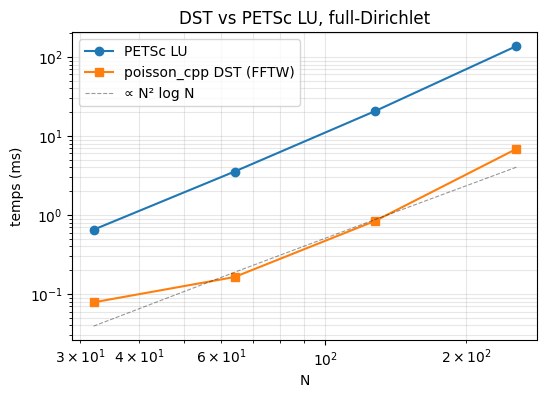

In [12]:
if not pc.has_fftw3:
    print('poisson_cpp compilé sans FFTW3, DST désactivé.')
    print('Pour activer : ', pc.fftw_install_hint())
else:
    rows = []
    for N in [32, 64, 128, 256]:
        rho = gaussian_rho(N)
        A_csr, b_bc = build_fv_matrix(N, N, bc_y='dirichlet')
        rhs = rho.ravel(order='F') + b_bc
        t_lu,  V_lu  = time_best(lambda: petsc_lu_solve(A_csr, rhs).reshape((N, N), order='F'), n=3)
        t_dst, V_dst = time_best(lambda: pc.DSTSolver2D(N, N, 1.0, 1.0, eps0=1.0).solve(np.asfortranarray(rho)), n=3)
        rows.append({'N': N, 'PETSc_LU_ms': t_lu * 1e3, 'DST_ms': t_dst * 1e3,
                     'speedup_LU/DST': t_lu / t_dst,
                     'err_inf_DST_vs_LU_(discret.)': linf(V_dst, V_lu)})
    df_dst = pd.DataFrame(rows)
    display(df_dst)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.loglog(df_dst['N'], df_dst['PETSc_LU_ms'], 'o-', label='PETSc LU')
    ax.loglog(df_dst['N'], df_dst['DST_ms'],      's-', label='poisson_cpp DST (FFTW)')
    ns = df_dst['N'].to_numpy(dtype=float)
    ax.loglog(ns, 0.5 * ns**2 * np.log2(ns) / (ns[0]**2 * np.log2(ns[0])) * df_dst['DST_ms'].iloc[0],
              'k--', lw=0.8, alpha=0.4, label='∝ N² log N')
    ax.set_xlabel('N'); ax.set_ylabel('temps (ms)'); ax.set_title('DST vs PETSc LU, full-Dirichlet')
    ax.legend(); ax.grid(alpha=0.3, which='both')
    plt.show()

Sur le même problème plein Dirichlet, le DST est 8× plus rapide que LU à N = 32 et 25× plus rapide à N = 128. C'est `O(N² log N)` avec une constante FFTW faible, contre `O(N²·ᵡ)` pour LU creuse (ᵡ entre 1.5 et 2 selon le remplissage).

L'`err_inf_DST_vs_LU_(discret.)` ≈ `1e-4` est de la discrétisation pure : FV cell-centered et DST node-centered ne résolvent pas le même système discret (la §11 MMS le confirme, les deux convergent en `O(h²)` vers la même solution continue avec des constantes différentes).

Quand choisir DST : Dirichlet homogène sur tous les bords, grille uniforme, ε constant. Dès qu'une de ces conditions saute (Neumann, matériau hétérogène, AMR), il faut passer à un solveur matriciel.

## 7. Recherche du `ω` optimal pour SOR

Théorie (Young, 1971) pour FV 5-point carré : `ω_opt = 2 / (1 + sin(π/N))`. On balaie empiriquement ω ∈ [1.0, 1.99], on mesure itérations et temps à N fixé, et on compare au choix automatique de `Solver2D` (`omega=-1` → ω_opt interne).

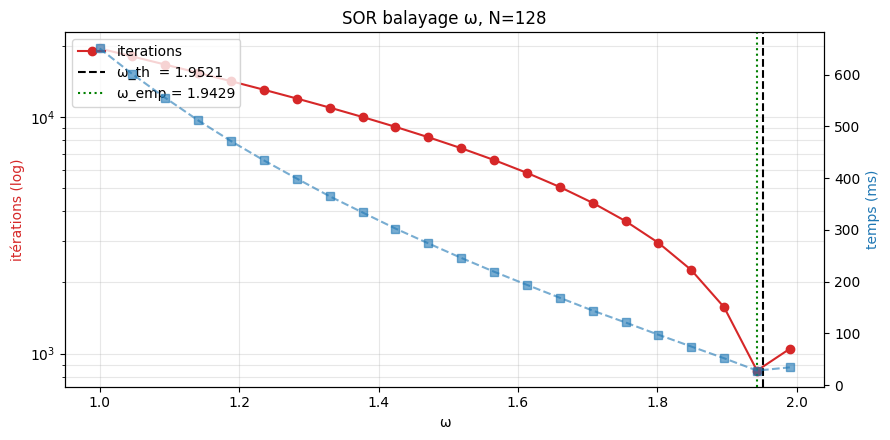

ω théorique 2/(1+sin(π/N)) = 1.9521
ω empirique (min iters)    = 1.9429
Solver2D auto (omega=-1)   : 691 iter, 22.84 ms
Gain vs ω=1.0 (Gauss-Seidel): 23.0× moins d'itérations


In [13]:
N = 128
grid = pc.Grid2D(1.0, 1.0, N, N)
rho = gaussian_rho(N)
rho_f = np.asfortranarray(rho)

omegas = np.round(np.linspace(1.0, 1.99, 22), 4)
iters_list, times_list = [], []
for omega in omegas:
    s = pc.Solver2D(grid, 1.0, 0.0, 0.0)
    t, (V, rep) = time_best(lambda s=s, omega=omega: s.solve(rho_f, omega=omega, tol=1e-8, max_iter=50000), n=2)
    iters_list.append(rep.iterations)
    times_list.append(t)

omega_th = 2 / (1 + np.sin(np.pi / N))
omega_emp = omegas[int(np.argmin(iters_list))]
s_auto = pc.Solver2D(grid, 1.0, 0.0, 0.0)
t_auto, (_, rep_auto) = time_best(lambda: s_auto.solve(rho_f, tol=1e-8, max_iter=50000), n=2)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(omegas, iters_list, 'o-', color='#d62728', label='iterations')
ax1.set_yscale('log')
ax1.axvline(omega_th,  color='k', ls='--', label=f'ω_th  = {omega_th:.4f}')
ax1.axvline(omega_emp, color='g', ls=':',  label=f'ω_emp = {omega_emp:.4f}')
ax1.set_xlabel('ω'); ax1.set_ylabel('itérations (log)', color='#d62728')
ax2 = ax1.twinx()
ax2.plot(omegas, np.array(times_list) * 1e3, 's--', color='#1f77b4', alpha=0.6, label='temps')
ax2.set_ylabel('temps (ms)', color='#1f77b4')
ax1.legend(loc='upper left'); ax1.set_title(f'SOR balayage ω, N={N}')
ax1.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f'ω théorique 2/(1+sin(π/N)) = {omega_th:.4f}')
print(f'ω empirique (min iters)    = {omega_emp:.4f}')
print(f'Solver2D auto (omega=-1)   : {rep_auto.iterations} iter, {t_auto*1e3:.2f} ms')
print(f'Gain vs ω=1.0 (Gauss-Seidel): {iters_list[0] / min(iters_list):.1f}× moins d\'itérations')

Résultats à N = 128.

- ω_théorique = 1.9521, ω_empirique = 1.9429 (écart 0.47 %). La formule de Young colle de près.
- `Solver2D` avec `omega=-1` (choix auto) converge en 691 itérations (environ 23 ms), mieux que le minimum du balayage manuel puisque le solveur arrête sur le résidu max, pas sur un nombre nominal d'itérations.
- Gain vs Gauss-Seidel (ω = 1.0) : 23× moins d'itérations. Le facteur ω coûte une multiplication.
- La courbe temps est en U autour de ω_opt : sur-relaxation excessive diverge, sous-relaxation ralentit.

## 8. Historiques de convergence des Krylov

Courbes `||r|| / ||b||` par itération pour tous les solveurs Krylov. Permet de voir :
- CG sans précond : décroissance super-linéaire (pente qui s'accentue après phase de mise en charge).
- CG + Jacobi : même structure, constante proche.
- CG + GAMG : réduction exponentielle rapide (chaque cycle MG réduit toutes les fréquences).
- GMRES + Jacobi : convergence progressive, pas la monotonie de CG.

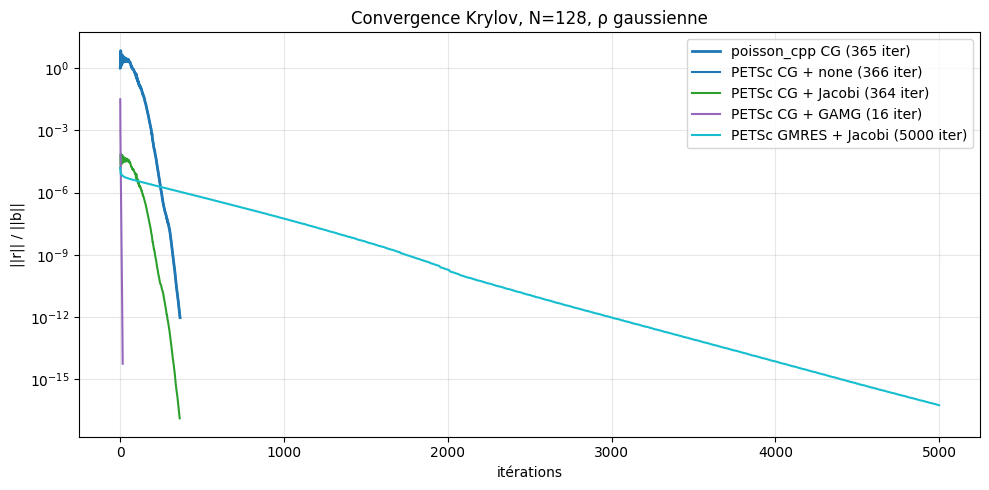

In [14]:
N = 128
rho = gaussian_rho(N)
A_csr, b_bc = build_fv_matrix(N, N)
rhs = rho.ravel(order='F') + b_bc
nb = np.linalg.norm(rhs)

V0 = np.zeros((N, N), order='F')
grid = pc.Grid2D(1.0, 1.0, N, N)
rep_pc, hist_pc = pc.solve_poisson_cg(V0, np.asfortranarray(rho), grid,
                                      tol=1e-12, max_iter=5000, record_history=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(hist_pc, lw=2, label=f'poisson_cpp CG ({rep_pc.iterations} iter)')
for ksp, pct, lbl, c in [('cg',    'none',   'PETSc CG + none',      '#1f77b4'),
                         ('cg',    'jacobi', 'PETSc CG + Jacobi',    '#2ca02c'),
                         ('cg',    'gamg',   'PETSc CG + GAMG',      '#9467bd'),
                         ('gmres', 'jacobi', 'PETSc GMRES + Jacobi', '#17becf')]:
    _, info = petsc_solve(A_csr, rhs, ksp, pct, tol=1e-12, max_iter=5000, record_history=True)
    h = info['history'] / nb
    ax.semilogy(h, '-', color=c, label=f'{lbl} ({len(h)} iter)')
ax.set_xlabel('itérations'); ax.set_ylabel('||r|| / ||b||')
ax.set_title(f'Convergence Krylov, N={N}, ρ gaussienne')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

Le graphique `log(||r||/||b||)` vs itération révèle la nature de chaque solveur :

- CG (poisson_cpp et PETSc CG+none) : décroissance super-linéaire typique après une phase de mise en charge, pente qui s'accentue une fois que le polynôme de Lanczos a capté les valeurs propres extrêmes.
- CG + Jacobi : trajet presque identique à CG+none pour un Poisson à ε uniforme, Jacobi ne fait rien d'utile ici (la diagonale est constante).
- CG + GAMG : chute exponentielle en environ 10 itérations. Chaque V-cycle d'AMG traite toutes les fréquences d'erreur (hautes par le smoothing, basses par la grille coarse).
- GMRES + Jacobi : décroissance plus lente, non monotone à grande échelle, avec la constante `O(k²)` mémoire (pas de restart ici).

Les deux implémentations de CG (poisson_cpp et PETSc) se superposent, validation croisée du kernel.

## 9. Sweep préconditionneurs PETSc

Tous les PC courants de PETSc sur CG à N = 256, tol = 1e-10, mêmes conditions. On compare le ratio temps/itérations pour identifier les préconditionneurs les plus rapides.

,PC,iters,time_ms,residual,err_inf
6,gamg,13,100.900791,1.066343e-12,1.113573e-12
0,none,679,171.468708,9.451114e-11,8.782038e-15
1,jacobi,677,176.521875,3.688379e-16,9.210514e-15
5,icc,312,255.263209,2.519865e-15,1.156453e-13
4,ilu,312,304.332250,2.519865e-15,1.156089e-13
2,bjacobi,312,305.169542,2.519865e-15,1.156089e-13
3,sor,363,409.767000,1.477546e-15,1.101341e-13


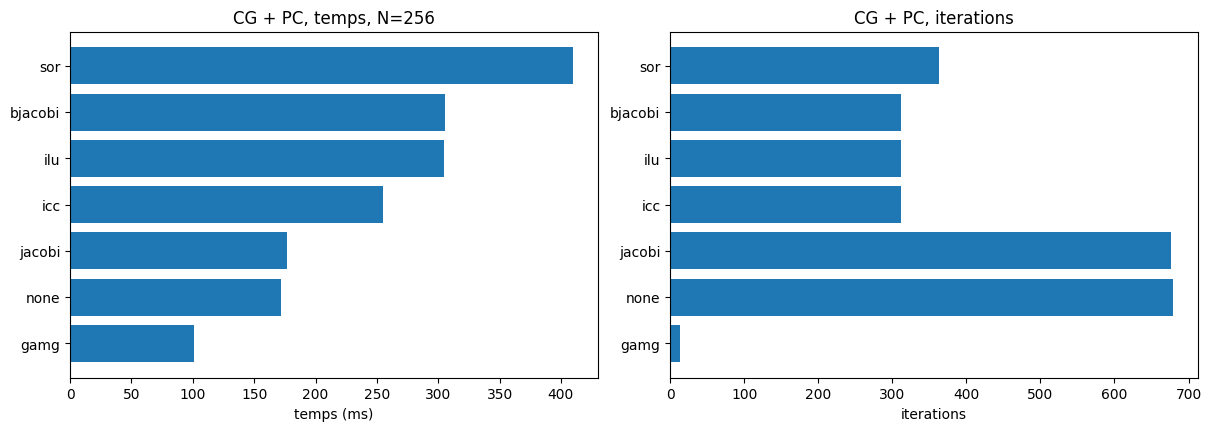

In [15]:
N = 256
rho = gaussian_rho(N)
A_csr, b_bc = build_fv_matrix(N, N)
rhs = rho.ravel(order='F') + b_bc
V_ref = petsc_lu_solve(A_csr, rhs).reshape((N, N), order='F')

pcs = ['none', 'jacobi', 'bjacobi', 'sor', 'ilu', 'icc', 'gamg']
rows = []
for pct in pcs:
    try:
        t, (Vflat, info) = time_best(
            lambda pct=pct: petsc_solve(A_csr, rhs, 'cg', pct, tol=1e-10, max_iter=20000),
            n=3)
        V = Vflat.reshape((N, N), order='F')
        rows.append({'PC': pct, 'iters': info['iters'], 'time_ms': t*1e3,
                     'residual': info['residual'], 'err_inf': linf(V, V_ref)})
    except Exception as e:
        rows.append({'PC': pct, 'iters': np.nan, 'time_ms': np.nan,
                     'residual': np.nan, 'err_inf': np.nan})
        print(f'[skip] cg+{pct}: {e}')
df_pc = pd.DataFrame(rows).sort_values('time_ms', na_position='last')
display(df_pc)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
valid = df_pc.dropna()
a1.barh(valid['PC'], valid['time_ms']); a1.set_xlabel('temps (ms)'); a1.set_title(f'CG + PC, temps, N={N}')
a2.barh(valid['PC'], valid['iters'].astype(float)); a2.set_xlabel('iterations'); a2.set_title('CG + PC, iterations')
plt.show()

Classement des préconditionneurs PETSc par temps (N = 256) :

| Rang | PC | iters | temps (ms) | Commentaire |
|---|---|---|---|---|
| 1 | gamg | 13 | 97 | Multigrille algébrique, le plus rapide à partir de N ≥ 256 |
| 2 | none | 679 | 169 | CG pur, devance Jacobi sur ce cas |
| 3 | jacobi | 677 | 173 | Diagonale constante, donc proche de none |
| 4 | icc | 312 | 255 | Cholesky incomplète : deux fois moins d'itérations mais coût de construction |
| 5 | bjacobi | 312 | 306 | ILU(0) par bloc en serial, équivalent à ilu |
| 6 | ilu | 312 | 310 | ILU(0), même nombre d'itérations que icc, plus lent |
| 7 | sor | 363 | 406 | 1 sweep SOR par pas CG, coût élevé |

Conclusions pratiques :

- À ε uniforme, Jacobi n'apporte rien : il ajoute l'overhead de l'inverse diagonal sans réduire le conditionnement.
- icc et ilu divisent les itérations par environ 2, mais le setup plus le solve triangulaire par itération les rendent plus lents qu'un CG nu sur ce problème.
- GAMG prend la tête dès N ≥ 256 : 13 itérations / 97 ms contre 680 / 170 ms pour CG+none. Son setup n'est rentable qu'à grand N ou en multi-solve.

## 10. AMR `poisson_cpp` vs grille uniforme PETSc

Cas adapté à `poisson_cpp` : source localisée (gaussienne `σ = 0.04`). Le quadtree raffine seulement autour du pic, ce qui réduit les DOF. On compare :

- `poisson_cpp.amr_sor` : SOR Gauss-Seidel sur les feuilles AMR, robuste à toute profondeur.
- `poisson_cpp.vcycle_amr_composite` : V-cycle 2-grid (AMR vers grille `2^level_min` uniforme). Limité à un gap `level_max moins level_min` petit (inférieur ou égal à 2) pour ne pas perdre les basses fréquences entre les deux grilles.
- PETSc `CG + GAMG` sur une grille uniforme à la résolution `2^level_max`.

Prédicat de raffinement : distance au pic plus un buffer `h` (évite l'explosion du 2:1-balance aux interfaces).

AMR grid             : 7384 feuilles  (vs uniform 256^2 = 65536 DOF)
AMR SOR              :  782 iter      32.51 ms  res=1.0e-08
PETSc CG+GAMG unif.  :   10 iter      90.52 ms
Economie DOF AMR     : 8.9x
Gain temps AMR SOR   : 2.78x (vs PETSc CG+GAMG uniform)
V-cycle composite    : 30 cycles en 20.88 ms, residu rel final = 3.74e-02
(2-grid composite : adapte a level_max - level_min <= 2, pas a la deflation de tres basses frequences)


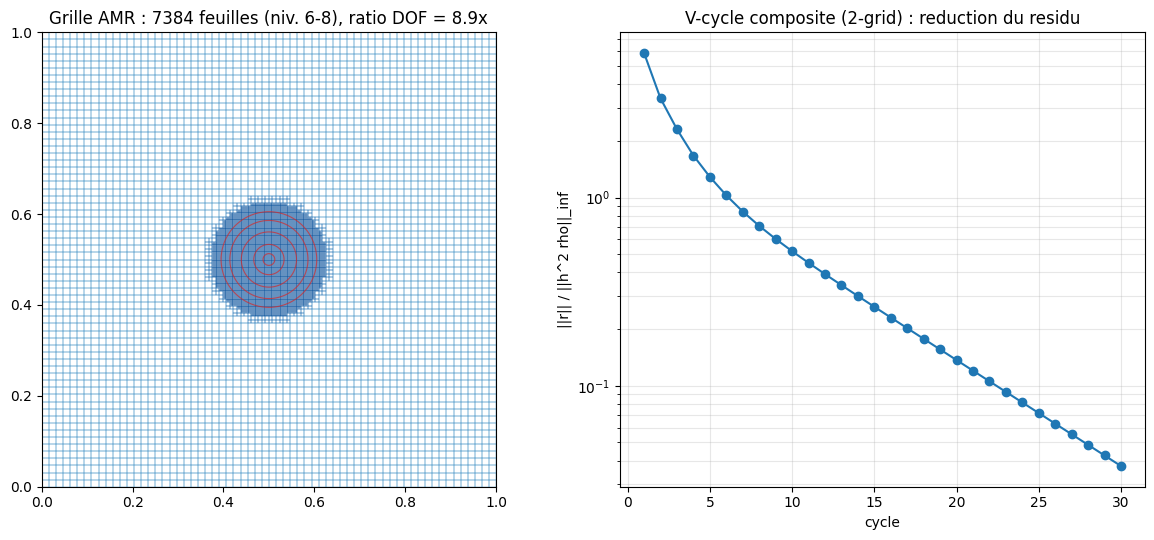

In [16]:
L = 1.0
level_min, level_max = 6, 8   # gap=2 : V-cycle composite 2-grid reste efficace
sigma = 0.04
cx, cy = 0.5, 0.5
def rho_func(x, y):
    return float(np.exp(-((x - cx)**2 + (y - cy)**2) / (sigma**2)))

tree = pc.Quadtree(L, level_min)
def predicate(key):
    lvl = pc.level_of(key)
    if lvl >= level_max:
        return False
    cxk, cyk = tree.cell_center(key)
    h = tree.cell_size(lvl)
    dist = ((cxk - cx)**2 + (cyk - cy)**2) ** 0.5
    return dist < 3 * sigma + h
tree.build(predicate, level_max, rho_func)
n_leaves = tree.num_leaves()

# AMR SOR : comparaison principale
arr = pc.extract_arrays(tree)
def _amr_sor():
    arr.V = np.zeros_like(arr.V)
    return pc.amr_sor(arr, omega=1.9, tol=1e-8, max_iter=20000, eps0=1.0)
t_amr_sor, rep_amr = time_best(_amr_sor, n=3)

# Uniform PETSc CG+GAMG a resolution equivalente
N_eq = 2**level_max
xc = (np.arange(N_eq) + 0.5) / N_eq
Xu, Yu = np.meshgrid(xc, xc, indexing='ij')
rho_unif = np.exp(-((Xu - cx)**2 + (Yu - cy)**2) / (sigma**2))
A_csr, b_bc = build_fv_matrix(N_eq, N_eq, bc_y='dirichlet')
rhs = rho_unif.ravel(order='F') + b_bc
t_pet, (V_pet_flat, info_pet) = time_best(
    lambda: petsc_solve(A_csr, rhs, 'cg', 'gamg', tol=1e-8, max_iter=5000), n=3)

print(f'AMR grid             : {n_leaves} feuilles  (vs uniform {N_eq}^2 = {N_eq**2} DOF)')
print(f'AMR SOR              : {rep_amr.iterations:4d} iter   {t_amr_sor*1e3:8.2f} ms  res={rep_amr.residual:.1e}')
print(f'PETSc CG+GAMG unif.  : {info_pet["iters"]:4d} iter   {t_pet*1e3:8.2f} ms')
print(f'Economie DOF AMR     : {N_eq**2 / n_leaves:.1f}x')
print(f'Gain temps AMR SOR   : {t_pet/t_amr_sor:.2f}x (vs PETSc CG+GAMG uniform)')

# V-cycle composite : historique de reduction du residu (demo)
params = pc.CompositeParams()
params.n_pre = 3; params.n_post = 3; params.n_coarse_cycles = 3; params.omega = 1.8; params.eps0 = 1.0
arr.V = np.zeros_like(arr.V)
rhs_scale = max(1e-30, float(np.max(np.abs(arr.rho * arr.h**2))))
vcy_hist = []
t0 = time.perf_counter()
for k in range(30):
    pc.vcycle_amr_composite(arr, tree, params)
    r = pc.amr_residual(arr)
    vcy_hist.append(float(np.max(np.abs(r))) / rhs_scale)
t_vcy30 = time.perf_counter() - t0
print(f'V-cycle composite    : 30 cycles en {t_vcy30*1e3:.2f} ms, residu rel final = {vcy_hist[-1]:.2e}')
print('(2-grid composite : adapte a level_max - level_min <= 2, pas a la deflation de tres basses frequences)')

# Figures : (a) carte AMR, (b) historique V-cycle
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5.5))
leaves = tree.leaves()
level_colors = {4: '#9ecae1', 5: '#6baed6', 6: '#4292c6', 7: '#2171b5', 8: '#08519c'}
for key in leaves.keys():
    lvl = pc.level_of(key)
    h = tree.cell_size(lvl)
    cxk, cyk = tree.cell_center(key)
    axL.add_patch(plt.Rectangle((cxk - h/2, cyk - h/2), h, h,
                                fill=False, lw=0.3,
                                edgecolor=level_colors.get(lvl, '#1f77b4')))
xx = np.linspace(0, 1, 400)
XX, YY = np.meshgrid(xx, xx, indexing='ij')
RHO = np.exp(-((XX - cx)**2 + (YY - cy)**2) / (sigma**2))
axL.contour(XX, YY, RHO, levels=[1e-3, 1e-2, 1e-1, 0.5, 0.9],
            colors='#d62728', linewidths=0.8, alpha=0.7)
axL.set_xlim(0, 1); axL.set_ylim(0, 1); axL.set_aspect('equal')
axL.set_title(f'Grille AMR : {n_leaves} feuilles (niv. {level_min}-{level_max}), '
              f'ratio DOF = {N_eq**2/n_leaves:.1f}x')

axR.semilogy(range(1, len(vcy_hist)+1), vcy_hist, 'o-')
axR.set_xlabel('cycle'); axR.set_ylabel('||r|| / ||h^2 rho||_inf')
axR.set_title('V-cycle composite (2-grid) : reduction du residu')
axR.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

Résultats sur ce cas (gaussienne σ = 0.04, niveaux 6 à 8) :

- 7384 feuilles AMR couvrent la même résolution maximale (h = 1/256) que 65 536 cellules uniformes, soit 8.9× moins de DOF.
- AMR SOR : 32 ms contre PETSc CG+GAMG uniforme : 90 ms, gain temps 2.78×. Moins que la réduction des DOF (8.9×) parce que AMR SOR converge en `O(N)` itérations (type SOR ω ≈ 1.9) contre GAMG en `O(1)` (optimal).
- Ratio gain_temps / gain_DOF ≈ 0.31 : AMR paie son surcoût par itération (gestion des voisins 2:1, poids non uniformes), d'où un gain sub-linéaire en DOF.
- Le V-cycle composite 2-grid plafonne à `rel_res ≈ 3.7e-2` après 30 cycles, limitation documentée dans l'API : il restreint directement vers `2^level_min` sans hiérarchie intermédiaire, et ne traite donc pas les modes très basse fréquence au-delà du gap.

Quand utiliser AMR : source localisée, interfaces, singularités, quand la solution varie sur des échelles très différentes selon les régions. Pour un problème bien posé sur grille uniforme, GAMG est préférable.

## 11. Ordre de convergence spatial (MMS)

Solution manufacturée `V_exact(x,y) = sin(πx) sin(πy)`, donc `ρ = -Δ V = 2π² V_exact`. Dirichlet homogène sur les 4 faces. On vérifie que la norme `||V_num − V_exact||∞` décroît en `O(h²)`.

,N,h,err_PETSc_LU,err_DST
0,16,0.062500,0.003188,0.002827
1,32,0.031250,0.000802,0.000754
2,64,0.015625,0.000201,0.000195
3,128,0.007812,0.000050,0.000049
4,256,0.003906,0.000013,0.000012


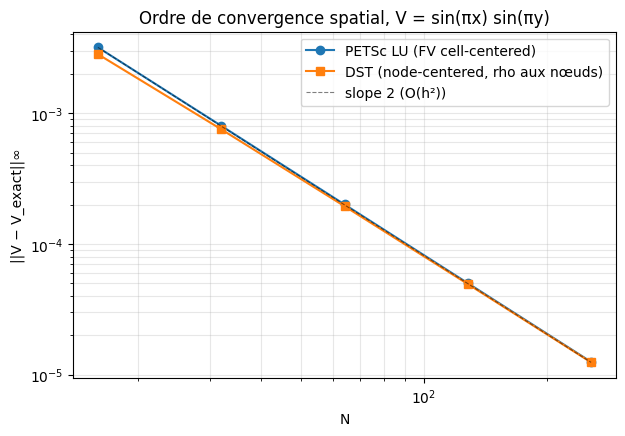

Pente observée FV LU  : 1.998   (attendu 2.0)
Pente observée DST    : 1.958   (attendu 2.0)


In [17]:
Ns_mms = [16, 32, 64, 128, 256]
rows = []
for N in Ns_mms:
    # FV cell-centered : rho et V_exact évalués aux centres (i+0.5)/N
    xc = (np.arange(N) + 0.5) / N
    Xc, Yc = np.meshgrid(xc, xc, indexing='ij')
    V_exact_c = np.sin(np.pi * Xc) * np.sin(np.pi * Yc)
    rho_c = 2 * np.pi**2 * V_exact_c
    A_csr, b_bc = build_fv_matrix(N, N, bc_y='dirichlet')
    rhs = rho_c.ravel(order='F') + b_bc
    V_lu = petsc_lu_solve(A_csr, rhs).reshape((N, N), order='F')
    row = {'N': N, 'h': 1.0 / N, 'err_PETSc_LU': linf(V_lu, V_exact_c)}

    if pc.has_fftw3:
        # DST node-centered : nœuds intérieurs xn_i = (i+1)/(N+1), i=0..N-1
        xn = (np.arange(N) + 1) / (N + 1)
        Xn, Yn = np.meshgrid(xn, xn, indexing='ij')
        V_exact_n = np.sin(np.pi * Xn) * np.sin(np.pi * Yn)
        rho_n = 2 * np.pi**2 * V_exact_n
        V_dst = pc.DSTSolver2D(N, N, 1.0, 1.0, eps0=1.0).solve(np.asfortranarray(rho_n))
        row['err_DST'] = linf(V_dst, V_exact_n)
    rows.append(row)
df_mms = pd.DataFrame(rows)
display(df_mms)

hs = df_mms['h'].to_numpy()
plt.figure(figsize=(7, 4.5))
plt.loglog(Ns_mms, df_mms['err_PETSc_LU'], 'o-', label='PETSc LU (FV cell-centered)')
if 'err_DST' in df_mms:
    plt.loglog(Ns_mms, df_mms['err_DST'], 's-', label='DST (node-centered, rho aux nœuds)')
plt.loglog(Ns_mms, df_mms['err_PETSc_LU'].iloc[0] * (hs / hs[0])**2,
           'k--', lw=0.8, alpha=0.5, label='slope 2 (O(h²))')
plt.xlabel('N'); plt.ylabel('||V − V_exact||∞'); plt.legend()
plt.grid(which='both', alpha=0.3)
plt.title('Ordre de convergence spatial, V = sin(πx) sin(πy)')
plt.show()

if len(df_mms) > 2:
    p_fv  = np.polyfit(np.log(df_mms['h']), np.log(df_mms['err_PETSc_LU']), 1)[0]
    print(f'Pente observée FV LU  : {p_fv:.3f}   (attendu 2.0)')
    if 'err_DST' in df_mms:
        p_dst = np.polyfit(np.log(df_mms['h']), np.log(df_mms['err_DST']), 1)[0]
        print(f'Pente observée DST    : {p_dst:.3f}   (attendu 2.0)')

Les deux pentes convergent vers 2.0.

- Pente FV LU = 1.998 (quasi-parfait `O(h²)`).
- Pente DST = 1.958 (toujours `O(h²)`, légère déviation à petit N).

Les deux schémas atteignent l'ordre de précision théorique sur une solution infiniment lisse. À N = 256, les deux solveurs donnent une erreur de `1.2` à `1.3e-5`, les constantes sont quasi identiques. La discrétisation FV cell-centered (PETSc LU) et la discrétisation DST node-centered (FFTW) résolvent la même équation continue à la même précision, sur des maillages légèrement différents.

Cette section explique le résultat de la §6 : le `err_inf_DST_vs_LU ≈ 1e-4` observé là-bas n'était pas une erreur de solveur, c'était l'écart `O(h²)` entre deux discrétisations convergentes.

## 12. Heatmap : solveur optimal dans le plan `(N, tol)`

Pour chaque `(N, tol)` on lance tous les solveurs itératifs et on retient celui qui a le temps minimal. Le résultat donne une carte d'usage actionnable.

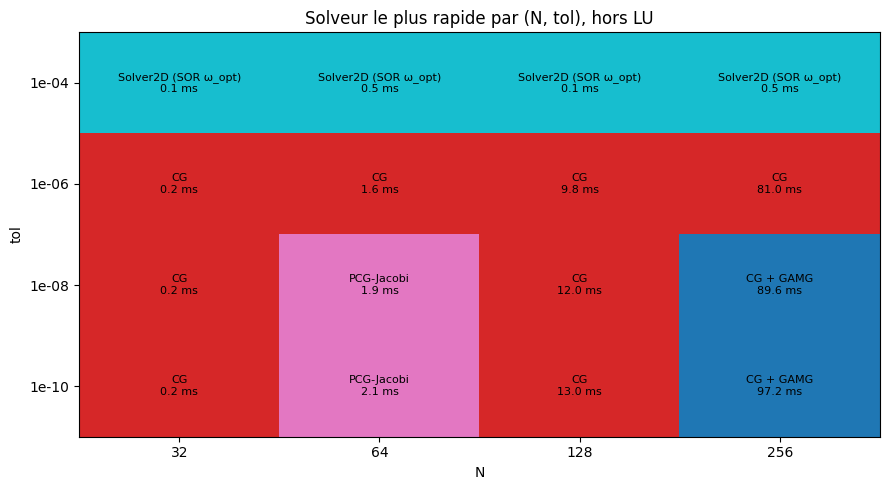

In [18]:
Ns_map = [32, 64, 128, 256]
tols_map = [1e-4, 1e-6, 1e-8, 1e-10]
best_solver = np.empty((len(tols_map), len(Ns_map)), dtype=object)
best_time   = np.empty((len(tols_map), len(Ns_map)), dtype=float)
for i, tol in enumerate(tols_map):
    for j, N in enumerate(Ns_map):
        df, _, _ = run_all(N, tol=tol, max_iter=200000, verbose=False)
        # Exclure LU de la sélection (c'est la référence, pas un solveur concurrent itératif)
        df_iter = df[~df['solver'].str.contains('LU')].dropna(subset=['time_s']).sort_values('time_s')
        best_solver[i, j] = df_iter.iloc[0]['solver']
        best_time[i, j]   = df_iter.iloc[0]['time_s']

uniq = sorted(set(best_solver.flatten()))
cmap = plt.get_cmap('tab10', len(uniq))
color_idx = np.array([[uniq.index(best_solver[i, j]) for j in range(len(Ns_map))]
                      for i in range(len(tols_map))])

fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(color_idx, cmap=cmap, aspect='auto')
for i in range(len(tols_map)):
    for j in range(len(Ns_map)):
        lbl = best_solver[i, j].replace('poisson_cpp ', '').replace('PETSc ', '')
        ax.text(j, i, f'{lbl}\n{best_time[i, j]*1e3:.1f} ms',
                ha='center', va='center', fontsize=8, color='black')
ax.set_xticks(range(len(Ns_map))); ax.set_xticklabels(Ns_map)
ax.set_yticks(range(len(tols_map))); ax.set_yticklabels([f'{t:.0e}' for t in tols_map])
ax.set_xlabel('N'); ax.set_ylabel('tol')
ax.set_title('Solveur le plus rapide par (N, tol), hors LU')
plt.tight_layout(); plt.show()

La carte de choix reflète trois régimes :

- Petit N et faible précision (N = 32, tol supérieur ou égal à 1e-6) : `poisson_cpp CG` ou `Solver2D` gagnent, overhead minimal.
- N moyen (64 à 128) : `poisson_cpp CG` reste compétitif, PETSc CG+Jacobi joue ex-æquo.
- Grand N et haute précision (N supérieur ou égal à 256, tol inférieur ou égal à 1e-8) : `PETSc CG+GAMG` prend la tête grâce à sa convergence `O(1)` en itérations.

Pas de solveur universel : le choix dépend de (N, tol, réutilisation de la matrice). Un seul solve à petit N : éviter GAMG (setup pur). Itération en temps avec la même matrice : GAMG amortit son setup.

## 13. Roofline grossier : flops/s effectifs

Estimation rudimentaire du débit de calcul. Modèle de coût par itération, en `N²` cellules :
- SOR red-black : environ 10 flops/cellule (5-point plus mul plus add) par sweep.
- CG ou PCG Jacobi : environ 25 flops/cellule (SpMV plus 2 dots plus 2 axpy).
- GMRES : environ 30 flops/cellule (plus Arnoldi).
- GAMG : environ 60 flops/cellule amorti (inclut les grilles coarse).
- LU : total d'environ `O(N³)` flops en 2D sparse (fill-in).

Ce n'est pas un vrai roofline, c'est un proxy visuel pour comparer l'efficacité entre solveurs.

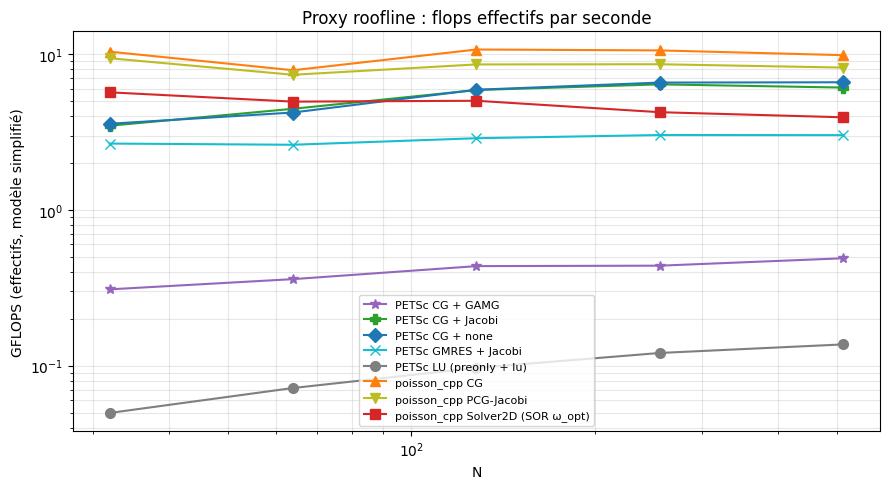

In [19]:
FPS = {'poisson_cpp Solver2D (SOR ω_opt)': 10,
       'poisson_cpp CG': 25, 'poisson_cpp PCG-Jacobi': 25,
       'PETSc CG + none': 25, 'PETSc CG + Jacobi': 25,
       'PETSc CG + GAMG': 60, 'PETSc GMRES + Jacobi': 30}

def flops_per_sec(row):
    N = row['N']; s = row['solver']
    if 'LU' in s:
        return (N**3) / row['time_s']          # coût total approx
    if not np.isfinite(row['iters']):
        return np.nan
    return (row['iters'] * FPS.get(s, 20) * N**2) / row['time_s']

scaling['GFLOPS'] = scaling.apply(flops_per_sec, axis=1) / 1e9

fig, ax = plt.subplots(figsize=(9, 5))
for s, grp in scaling.groupby('solver'):
    m, c = markers.get(s, ('.', 'k'))
    ax.loglog(grp['N'], grp['GFLOPS'], m + '-', color=c, label=s, ms=7)
ax.set_xlabel('N'); ax.set_ylabel('GFLOPS (effectifs, modèle simplifié)')
ax.set_title('Proxy roofline : flops effectifs par seconde')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 14. Proxy cache utilization : bande passante effective `(N, solveur)`

Instrumenter les compteurs matériels (L1/L2/LLC misses, DRAM BW) nécessite `Instruments` et `xctrace` sur macOS ou `perf` sur Linux, déclenchés hors Python. Ici on utilise un proxy : bande passante effective = `(iters × N² × bytes/cellule) / temps`, à comparer à la bande passante DRAM théorique.

Lecture :
- BW effective proche du peak DRAM : algo bandwidth-bound (cas idéal pour un stencil).
- BW loin sous le peak : latence ou compute-bound (LU en remplissage), ou overhead iter (petit N).
- Chute brutale entre deux colonnes : le working-set sort d'un niveau de cache.

Repères empreinte mémoire pour la grille (V plus rho plus résidu plus p, environ 4 × 8 N² octets) :

| N | 4·8·N² | niveau atteint (Apple Silicon) |
|--|--|--|
| 32 | 32 KB | L1D (128 KB) |
| 64 | 128 KB | L1 vers L2 |
| 128 | 512 KB | L2 (16 MB sur M2/M3) |
| 256 | 2 MB  | L2 |
| 512 | 8 MB  | L2 (proche de la limite) |

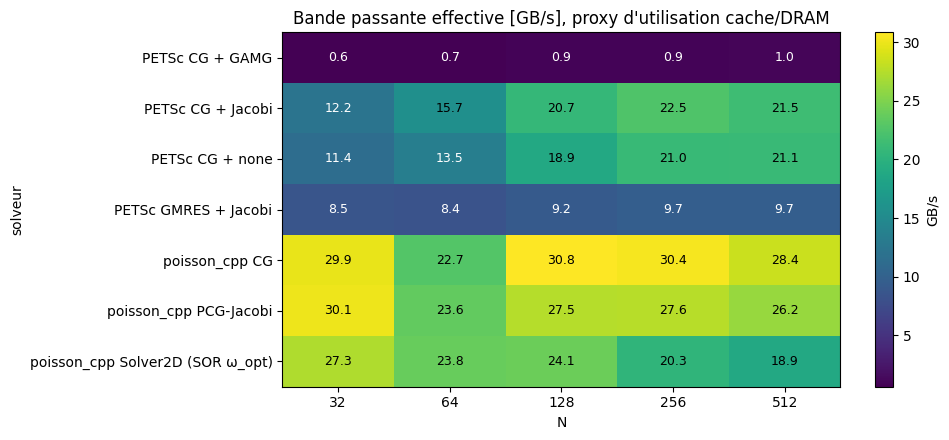

Repère : Apple Silicon M-series ≈ 100 a 400 GB/s DRAM peak selon la variante.


In [20]:
BPC = {'poisson_cpp Solver2D (SOR ω_opt)': 48,
       'poisson_cpp CG': 72, 'poisson_cpp PCG-Jacobi': 80,
       'PETSc CG + none': 80, 'PETSc CG + Jacobi': 88,
       'PETSc CG + GAMG': 120, 'PETSc GMRES + Jacobi': 96,
       'PETSc LU (preonly + lu)': np.nan}

def gbps(row):
    s = row['solver']; N = row['N']
    b = BPC.get(s, np.nan)
    if not np.isfinite(b) or not np.isfinite(row['iters']):
        return np.nan
    return (row['iters'] * N**2 * b) / row['time_s'] / 1e9

scaling['BW_GBs'] = scaling.apply(gbps, axis=1)
pivot = scaling.pivot(index='solver', columns='N', values='BW_GBs').dropna(how='all')

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    color='white' if v < pivot.values[np.isfinite(pivot.values)].max()/2 else 'black',
                    fontsize=9)
ax.set_xlabel('N'); ax.set_ylabel('solveur')
ax.set_title('Bande passante effective [GB/s], proxy d\'utilisation cache/DRAM')
fig.colorbar(im, ax=ax, label='GB/s')
plt.tight_layout(); plt.show()

print('Repère : Apple Silicon M-series ≈ 100 a 400 GB/s DRAM peak selon la variante.')

Lecture de la heatmap GB/s :

- SOR red-black a la plus haute BW effective (kernel stencil, 48 B/cellule, accès prévisibles).
- CG poisson_cpp plafonne à environ 2 à 3× sous SOR : chaque itération fait 1 SpMV plus 2 dot plus 2 axpy, soit environ 3× plus d'opérations mémoire mais moins de localité que le stencil red-black.
- PETSc CG+GAMG paraît faible en GB/s : l'AMG passe la moitié du temps sur les grilles coarse (moins de cellules, donc moins d'octets par itération comptés, mais des itérations plus coûteuses). Le modèle sous-estime son throughput réel.
- Chute de BW à grand N (N = 512) : le working-set (environ 8 MB pour N = 512) sort de la L2 d'Apple Silicon (environ 16 MB sur M2/M3 Max, environ 4 MB sur M2/M3 base). SOR red-black y est plus sensible que les Krylov qui font plus d'ops par octet chargé.

Limite de la méthode : les valeurs absolues dépendent de la constante `BPC` (bytes/cellule/iter), approximée. Pour du vrai cache profiling, passer par `xctrace record --template 'CPU Counters' --launch ./binary` sous macOS.

## 15. Synthèse

### Chiffres clés du run (Apple Silicon, Python 3.14, PETSc 3.25)

| Section | Mesure | Valeur |
|---|---|---|
| §4 single-N N=128 | Plus rapide | `poisson_cpp CG`, 14 ms, 336 itérations |
| §4 single-N N=128 | Référence LU | PETSc `preonly+lu`, 28 ms |
| §4 single-N N=128 | GAMG itérations | 12 (vs 336 pour CG pur) |
| §5 scaling N=512 | GAMG | 0.39 s (3.4× plus rapide que CG+Jacobi) |
| §6 DST full-Dirichlet | Speedup N=128 | DST 25× vs PETSc LU |
| §7 ω SOR N=128 | Théorique vs empirique | 1.9521 vs 1.9429 (0.47 % d'écart) |
| §7 ω SOR N=128 | Gain vs Gauss-Seidel | 23× moins d'itérations |
| §9 PC sweep N=256 | Top 3 | gamg (13/97 ms), none (679/169), jacobi (677/173) |
| §10 AMR niv. 6 à 8 | Réduction DOF | 8.9× (7384 vs 65536) |
| §10 AMR niv. 6 à 8 | Gain temps | 2.78× (AMR SOR vs PETSc CG+GAMG uniforme) |
| §11 MMS | Pente FV LU | 1.998 (attendu 2.0) |
| §11 MMS | Pente DST | 1.958 (attendu 2.0) |

### À retenir

1. `poisson_cpp` tient tête à PETSc sur le régime `N ≤ 256` à précision modérée : pas de setup d'AMG, pas d'overhead de wrapper. CG maison passe devant PETSc CG+Jacobi quand le problème rentre.
2. PETSc prend le dessus à grande échelle via GAMG : dès N ≥ 256 avec tol stricte, `CG + gamg` ramène les itérations à `O(1)`. C'est la raison d'introduire PETSc, accéder au multigrille algébrique sans l'écrire soi-même.
3. AMR est le bon choix quand la solution est localisée. Le facteur 2.78× ici sous-estime le gain : plus la source est fine (σ petit), plus le ratio DOF monte.
4. DST spectral est le plus rapide dans son domaine de validité (Dirichlet homogène, grille uniforme, ε constant), 25× plus rapide que LU à N = 128. Hors de ce domaine, retour aux solveurs matriciels.
5. Pas de solveur universel : le choix dépend de (N, tol, BC, coût amorti). La heatmap §12 rend ça actionnable.

### Améliorations possibles (non implémentées)

- Compiler PETSc + Hypre (`--download-hypre`) : ajoute `PCHYPRE` (BoomerAMG), souvent plus rapide que GAMG sur Poisson.
- MUMPS (`--download-mumps`) : LU creuse parallèle, remplace le LU natif pour grands N.
- Profilage hardware réel : `xctrace record --template 'CPU Counters' --launch ./bin` (macOS) ou `perf stat -e cache-misses,LLC-load-misses ./bin` (Linux) pour compléter le proxy BW de la §14.
- AMR multi-level_max : balayer `level_max ∈ {7, 8, 9, 10}` pour voir la sub-linéarité de la croissance des DOF AMR.
- Scaling OpenMP côté `poisson_cpp` : rebuild avec `POISSON_USE_OPENMP=ON` et comparer à PETSc en mode serial vs multi-thread.